In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
res_csv = Path.cwd().parent / "data/sota_model_results.csv"

In [3]:
df = pd.read_csv(res_csv)

In [4]:
# relevant columns
relevant_cols = ["task", "assistant_model", "conv_type", "accuracy_all", "n_convs"]
df_relevant = df[relevant_cols]
df_relevant

,task,assistant_model,conv_type,accuracy_all,n_convs
0,actions,gpt-5,full,0.857143,105
1,actions,gpt-5,sharded,0.561905,105
2,actions,gpt-5-chat,full,0.971429,105
3,actions,gpt-5-chat,sharded,0.750000,104
4,actions,gpt-5-mini,full,0.809524,105
5,actions,gpt-5-mini,sharded,0.557692,104
6,actions,gpt-5.1,full,0.676190,105
7,actions,gpt-5.1,sharded,0.572816,103
8,actions,gpt-5.1-chat,full,0.914286,105
9,actions,gpt-5.1-chat,sharded,0.576923,104


In [5]:
# artificial analysis intelligence index values
# all medium reasoning effort
a2i2 = {
    "gpt-5-mini": 39,
    "gpt-5": 42,
    # MADE UP VALUE INTERPOLATED BETWEEN 5 AND 5.2
    # ARTIFICIAL ANALYSIS DOES NOT HAVE GPT-5.1 (medium)
    "gpt-5.1": 44, 
    "gpt-5.2": 47,
}

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

relevant_cols = ["task", "assistant_model", "conv_type", "accuracy_all", "n_convs"]

MODEL_ORDER = [
    "gpt-5-mini", "gpt-5", "gpt-5-chat",
    "gpt-5.1", "gpt-5.1-chat",
    "gpt-5.2", "gpt-5.2-chat",
]

CONV_ORDER = ["full", "sharded"]  # controls left/right bar order within each model


def plot_accuracy_by_task(
    df: pd.DataFrame,
    *,
    model_order=MODEL_ORDER,
    conv_order=CONV_ORDER,
    figsize=(10, 4),
    ylim=(0.0, 1.0),
    annotate_n_convs=False,
    title_prefix="Task",
    save_path=None,
):
    # Basic validation / subset
    missing = set(relevant_cols) - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {sorted(missing)}")
    d = df[relevant_cols].copy()

    # Ensure expected categories + ordering
    d["assistant_model"] = pd.Categorical(d["assistant_model"], categories=model_order, ordered=True)
    d["conv_type"] = pd.Categorical(d["conv_type"], categories=conv_order, ordered=True)

    # If you might have duplicates per (task, model, conv_type), aggregate safely
    # (weighted mean by n_convs; fall back to simple mean if n_convs missing/zero)
    def _agg(g: pd.DataFrame) -> pd.Series:
        acc = g["accuracy_all"].astype(float)
        n = g["n_convs"].astype(float).fillna(0)
        if (n > 0).any():
            w = n.clip(lower=0)
            return pd.Series({"accuracy_all": np.average(acc, weights=w), "n_convs": w.sum()})
        return pd.Series({"accuracy_all": acc.mean(), "n_convs": n.sum()})

    d = d.groupby(["task", "assistant_model", "conv_type"], as_index=False).apply(_agg).reset_index(drop=True)

    # Plot per task
    tasks = [t for t in d["task"].dropna().unique()]
    tasks.sort()

    for task in tasks:
        dt = d[d["task"] == task].copy()

        # Pivot to get conv_type columns for accuracy + n_convs
        acc_p = dt.pivot(index="assistant_model", columns="conv_type", values="accuracy_all").reindex(model_order)
        n_p = dt.pivot(index="assistant_model", columns="conv_type", values="n_convs").reindex(model_order)

        x = np.arange(len(model_order))
        width = 0.38  # bar width per conv_type

        fig, ax = plt.subplots(figsize=figsize)

        # Plot in fixed conv order so colors/legend are stable
        offsets = [-width / 2, width / 2] if len(conv_order) == 2 else np.linspace(-width, width, len(conv_order))
        bars = []
        for i, conv in enumerate(conv_order):
            y = acc_p[conv].to_numpy() if conv in acc_p.columns else np.full(len(model_order), np.nan)
            b = ax.bar(x + offsets[i], y, width=width, label=conv)
            bars.append((conv, b))

            if annotate_n_convs:
                nvals = n_p[conv].to_numpy() if conv in n_p.columns else np.full(len(model_order), np.nan)
                for rect, nval in zip(b, nvals):
                    if np.isfinite(rect.get_height()) and np.isfinite(nval) and nval > 0:
                        ax.annotate(
                            f"n={int(nval)}",
                            (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                            ha="center",
                            va="bottom",
                            fontsize=8,
                            xytext=(0, 3),
                            textcoords="offset points",
                        )

        ax.set_title(f"{title_prefix}: {task}")
        ax.set_ylabel("accuracy_all")
        ax.set_xticks(x)
        ax.set_xticklabels(model_order, rotation=25, ha="right")
        ax.set_ylim(*ylim)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="conv_type", frameon=False)

        plt.tight_layout()
        plt.show()

        if save_path:
            plt.savefig(save_path / f"{task}_accuracy_by_model.png")


# Usage:
# plot_accuracy_by_task(df, annotate_n_convs=True)

/var/folders/r1/ml049521017bkv2610b6fhbc0000gn/T/ipykernel_39493/2303996500.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d = d.groupby(["task", "assistant_model", "conv_type"], as_index=False).apply(_agg).reset_index(drop=True)
/var/folders/r1/ml049521017bkv2610b6fhbc0000gn/T/ipykernel_39493/2303996500.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  d = d.groupby(["task", "assistant_model", "conv_type"], as_index=False).apply(_agg).reset_index(drop=True)


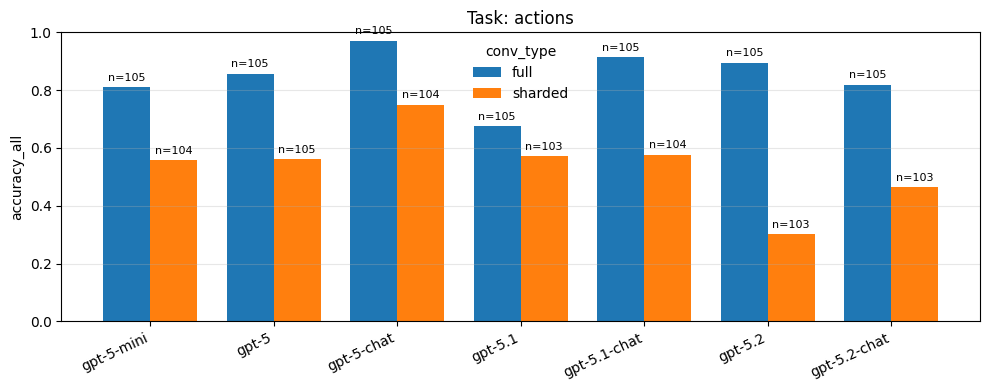

<Figure size 640x480 with 0 Axes>

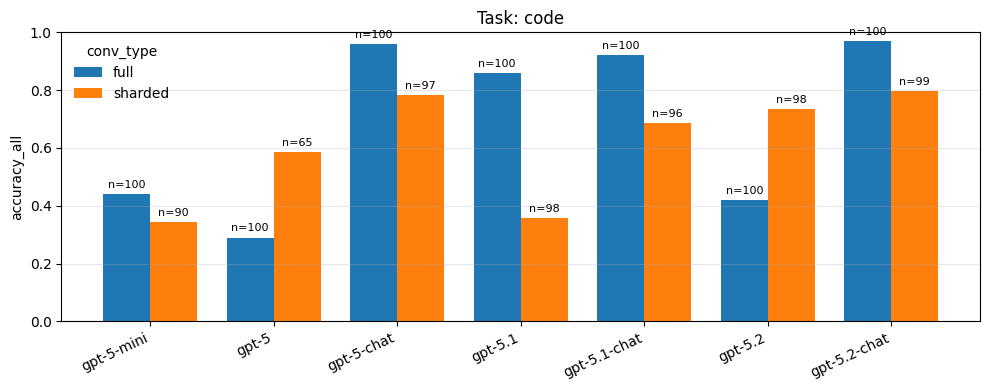

<Figure size 640x480 with 0 Axes>

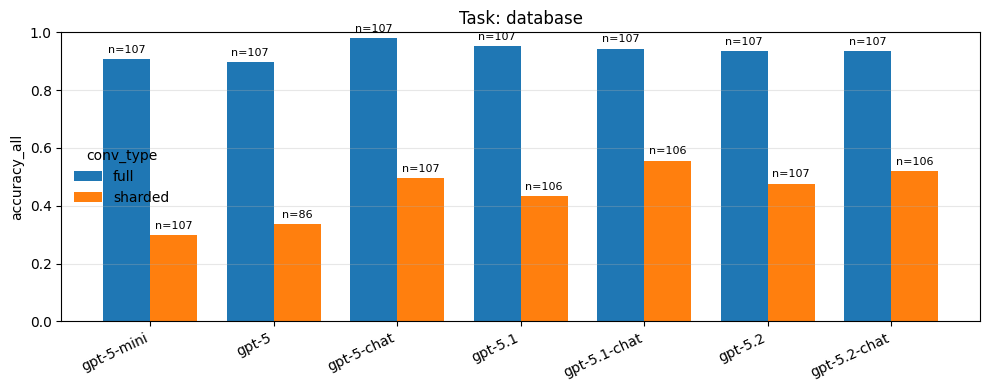

<Figure size 640x480 with 0 Axes>

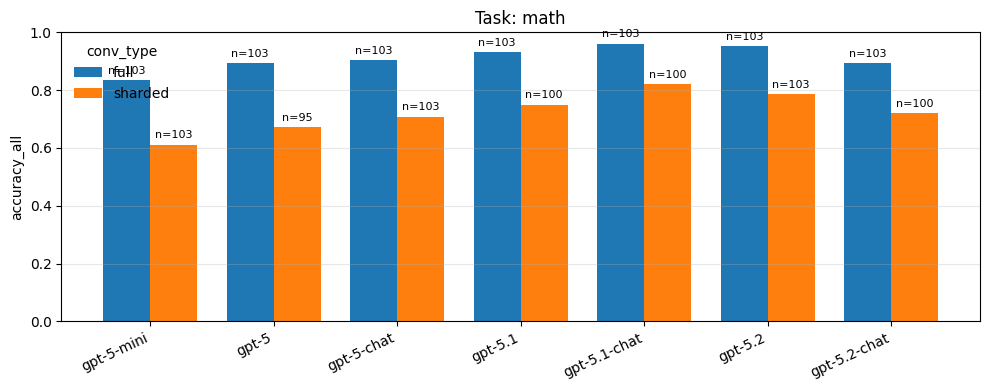

<Figure size 640x480 with 0 Axes>

In [9]:
save_dir = Path.cwd().parent / "data/plots"
save_dir.mkdir(exist_ok=True, parents=True)
plot_accuracy_by_task(df, annotate_n_convs=True, save_path=save_dir)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_BASES = ["gpt-5-mini", "gpt-5", "gpt-5.1", "gpt-5.2"]
CONV_TYPES = ["full", "sharded"]

def _is_chat_model(m: str) -> bool:
    return isinstance(m, str) and m.endswith("-chat")

def _base_of(m: str) -> str:
    return m[:-5] if _is_chat_model(m) else m  # strip "-chat"

def plot_perf_vs_intelligence(
    df: pd.DataFrame,
    intelligence_index: dict,
    *,
    task: str | None = None,           # optionally plot one task; else aggregate across tasks
    aggregate="weighted",              # "weighted" by n_convs, or "mean"
    ylim=(0.0, 1.0),
    title_prefix="Perf vs Intelligence",
):
    # --- optionally filter task ---
    d = df.copy()
    if task is not None:
        d = d[d["task"] == task].copy()

    # keep only models we can map to x
    d["model_base"] = d["assistant_model"].map(_base_of)
    d = d[d["model_base"].isin(intelligence_index.keys())].copy()
    d = d[d["conv_type"].isin(CONV_TYPES)].copy()

    if d.empty:
        raise ValueError("No rows left after filtering (task/model/conv_type).")

    # --- aggregate to one point per (assistant_model, conv_type) ---
    if aggregate == "weighted" and "n_convs" in d.columns:
        def _wmean(g):
            acc = g["accuracy_all"].astype(float)
            w = g["n_convs"].astype(float).fillna(0).clip(lower=0)
            if (w > 0).any():
                return np.average(acc, weights=w)
            return acc.mean()

        agg = (
            d.groupby(["assistant_model", "model_base", "conv_type"], as_index=False)
             .apply(lambda g: pd.Series({"accuracy_all": _wmean(g)}))
             .reset_index(drop=True)
        )
    else:
        agg = (
            d.groupby(["assistant_model", "model_base", "conv_type"], as_index=False)["accuracy_all"]
             .mean()
        )

    agg["is_chat"] = agg["assistant_model"].map(_is_chat_model)
    agg["x_intel"] = agg["model_base"].map(intelligence_index)

    # --- make the 4 categories ---
    # (matplotlib will assign colors automatically; no explicit colors)
    categories = [
        ("full perf, base model",    (False, "full"),    "o"),
        ("sharded perf, base model", (False, "sharded"), "s"),
        ("full perf, chat model",    (True,  "full"),    "^"),
        ("sharded perf, chat model", (True,  "sharded"), "D"),
    ]

    # ========= Plot 1: performance scatter =========
    fig, ax = plt.subplots(figsize=(8, 5))
    for label, (is_chat, conv), marker in categories:
        sub = agg[(agg["is_chat"] == is_chat) & (agg["conv_type"] == conv)]
        if sub.empty:
            continue
        ax.scatter(sub["x_intel"], sub["accuracy_all"], label=label, marker=marker)

        # Optional: annotate with model name (comment out if too busy)
        for _, r in sub.iterrows():
            ax.annotate(
                r["assistant_model"],
                (r["x_intel"], r["accuracy_all"]),
                textcoords="offset points",
                xytext=(5, 3),
                fontsize=8,
            )

    ax.set_title(f"{title_prefix}" + (f" — task={task}" if task else " — aggregated"))
    ax.set_xlabel("Intelligence index")
    ax.set_ylabel("accuracy_all")
    ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # ========= Plot 2: ratio scatter + best fit line =========
    # ratio per (assistant_model) i.e., base and chat variants separately
    wide = (
        agg.pivot_table(
            index=["assistant_model", "model_base", "is_chat", "x_intel"],
            columns="conv_type",
            values="accuracy_all",
            aggfunc="mean",
        )
        .reset_index()
    )

    wide["ratio_sharded_over_full"] = wide["sharded"] / wide["full"]
    ratio_df = wide[np.isfinite(wide["ratio_sharded_over_full"])].copy()

    fig, ax = plt.subplots(figsize=(8, 5))

    # scatter (base vs chat as different markers)
    base_pts = ratio_df[ratio_df["is_chat"] == False]
    chat_pts = ratio_df[ratio_df["is_chat"] == True]

    if not base_pts.empty:
        ax.scatter(base_pts["x_intel"], base_pts["ratio_sharded_over_full"],
                   label="ratio (base)", marker="o")
    if not chat_pts.empty:
        ax.scatter(chat_pts["x_intel"], chat_pts["ratio_sharded_over_full"],
                   label="ratio (chat)", marker="^")

    # best fit line across ALL ratio points (base+chat)
    x = ratio_df["x_intel"].to_numpy(dtype=float)
    y = ratio_df["ratio_sharded_over_full"].to_numpy(dtype=float)

    if len(x) >= 2:
        m, b = np.polyfit(x, y, deg=1)
        xs = np.linspace(x.min(), x.max(), 200)
        ys = m * xs + b
        ax.plot(xs, ys, label=f"best fit: y={m:.3g}x+{b:.3g}")

    # optional annotations
    for _, r in ratio_df.iterrows():
        ax.annotate(
            r["assistant_model"],
            (r["x_intel"], r["ratio_sharded_over_full"]),
            textcoords="offset points",
            xytext=(5, 3),
            fontsize=8,
        )

    ax.set_title("Sharded / Full ratio vs Intelligence" + (f" — task={task}" if task else " — aggregated"))
    ax.set_xlabel("Intelligence index")
    ax.set_ylabel("sharded_perf / full_perf")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return agg, ratio_df


# ---- Example usage ----
# intelligence_index = {
#   "gpt-5-mini": 0.42,
#   "gpt-5": 0.71,
#   "gpt-5.1": 0.83,
#   "gpt-5.2": 0.90,
# }
# agg_points, ratio_points = plot_perf_vs_intelligence(df, intelligence_index, task=None)
# agg_points, ratio_points = plot_perf_vs_intelligence(df, intelligence_index, task="math")

/var/folders/r1/ml049521017bkv2610b6fhbc0000gn/T/ipykernel_39493/839554142.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"accuracy_all": _wmean(g)}))


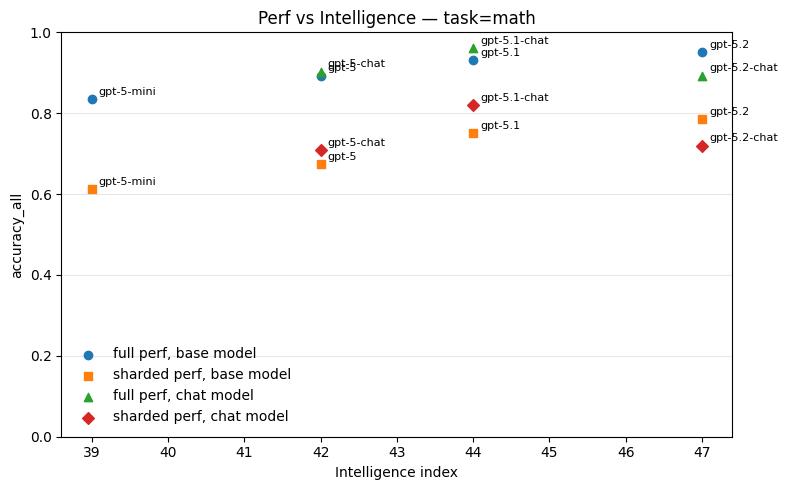

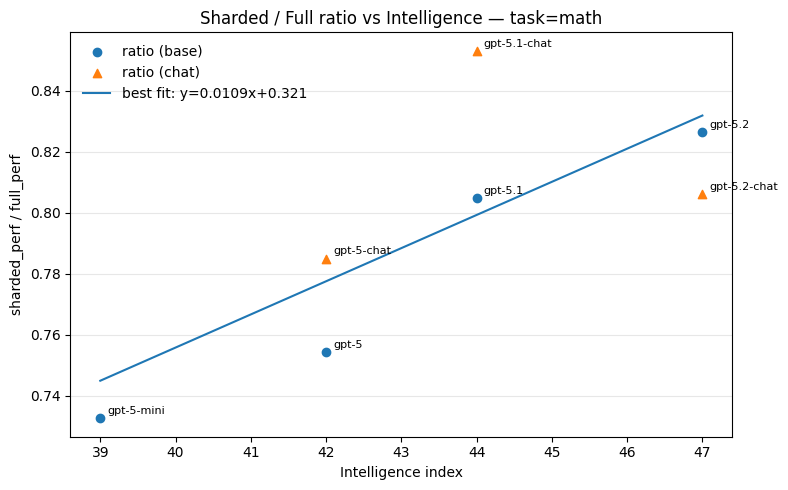

In [11]:
# agg_points, ratio_points = plot_perf_vs_intelligence(df, intelligence_index, task=None)
agg_points, ratio_points = plot_perf_vs_intelligence(df, a2i2, task="math")